<a href="https://colab.research.google.com/github/scardenol/Stochastic_Optimization_2026/blob/main/Algoritmos/clase1_energia_SAA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:rgb(213,80,0)">Script para resolver el Problema de Generación de Energia via SAA</span>

In [ ]:
% Limpiar entorno y consola
clear; clc; close all;


## 1. Definir Parámetros del Problema

In [ ]:
c = 20;
p = 50;
b = 70;
s = 10;


## Parámetros de la distribución de demanda y SAA

In [ ]:
% Demanda modelada con distribución Log-Normal
mu_ln = 6.9;
sigma_ln = 0.2;
N = 500; % # de escenarios/observaciones (sample size)


% Generar escenarios de demanda de una distribucion Log-Normal
rng (1); % seed, para reproducibilidad
xi = lognrnd(mu_ln, sigma_ln, N, 1);


## 2. Formular el Problema LP para linprog

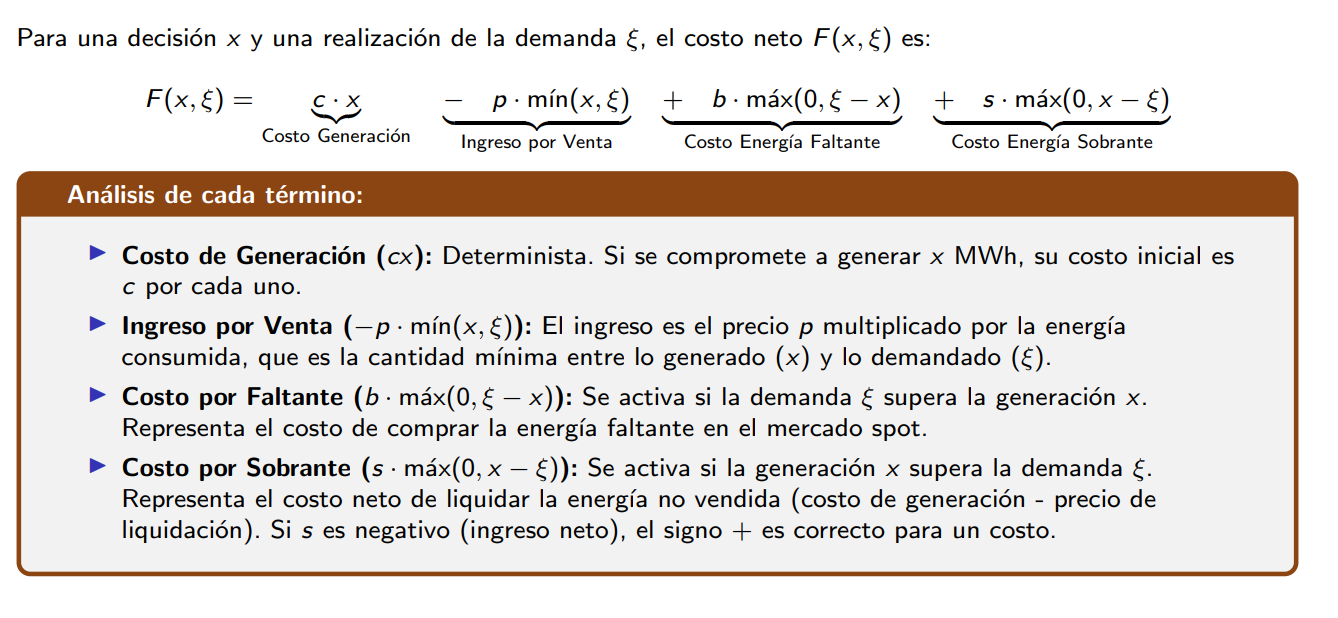

- **Variables:** $x,y_1 ,\ldotp \ldotp \ldotp ,y_N ,w_1 ,\ldotp \ldotp \ldotp ,w_N ,z_1 ,\ldotp \ldotp \ldotp ,z_N$, i.e., $3N+1$ variables
- **Objetivo:** $\min cx+\frac{1}{N}\sum_{i=1}^N \big(-py_i +bw_i +sz_i \big)$ $=f^T \left\lbrack \begin{array}{c} x\newline y_1 \newline \vdots \newline y_N \newline w_1 \newline \vdots \newline w_N \newline z_1 \newline \vdots \newline z_N  \end{array}\right\rbrack$


In [ ]:
% Función Objetivo
f = [c; (-p/N)*ones(N, 1); (b/N)*ones(N, 1); (s/N)*ones(N, 1)];
% Restricciones de Igualdad : Aeq * vars = beq
Aeq = zeros (2*N, 3*N + 1);
beq = zeros (2*N, 1);


for i = 1: N
    Aeq(i, 1+i) = 1; % y_i
    Aeq(i, 1+N+i) = 1; % w_i
    beq(i) = xi(i);
    Aeq(N+i, 1) = -1; % -x
    Aeq(N+i, 1+i) = 1; % y_i
    Aeq(N+i, 1+2*N+i) = 1; % z_i
end


% Cotas Inferiores (todas las variables son no-negativas)
lb = zeros (3*N+1, 1) ;


## 3. Resolver el el LP

In [ ]:
options = optimoptions ('linprog', 'Display', 'iter');
[sol , fval] = linprog(f, [], [], Aeq, beq, lb, [], options);

Running HiGHS 1.11.0: Copyright (c) 2025 HiGHS under MIT licence terms
LP   has 1000 rows; 1501 cols; 2500 nonzeros
Coefficient ranges:
  Matrix [1e+00, 1e+00]
  Cost   [2e-02, 2e+01]
  Bound  [0e+00, 0e+00]
  RHS    [6e+02, 2e+03]
Presolving model
500 rows, 1001 cols, 1500 nonzeros  0s
Dependent equations search running on 500 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
500 rows, 1001 cols, 1500 nonzeros  0s
Presolve : Reductions: rows 500(-500); columns 1001(-500); elements 1500(-1000)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0s
        500    -2.1679177076e+04 Pr: 0(0) 0s
Solving the original LP from the solution after postsolve
Model status        : Optimal
Simplex   iterations: 500
Objective value     : -2.1679177076e+04
P-D objective error :  4.6985665995e-15
HiGHS run time      :


## 4. Extraer y mostrar la solución óptima

In [ ]:
x_opt = sol (1);
fprintf('Cantidad Óptima a Generar (x*) = %.2f MWh \n', x_opt);

Cantidad Óptima a Generar (x*) = 1135.88 MWh

In [ ]:
fprintf('Costo Esperado (SAA) = %.2f\n', fval);

Costo Esperado (SAA) = -21679.18


## 5. Visualizar los Resultados


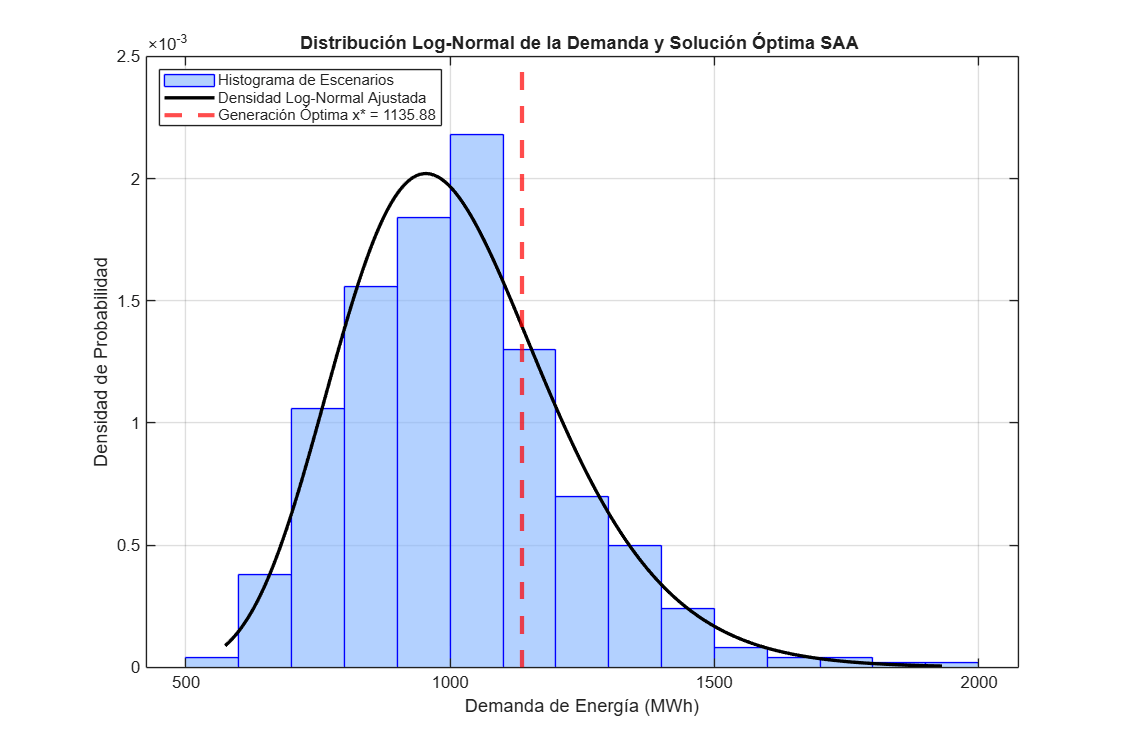

In [ ]:
figure('Position', [100, 100, 900, 600]);


% Histograma de la demanda
histogram(xi, 'Normalization', 'pdf', 'FaceColor', [0.5, 0.7, 1] , 'EdgeColor', 'b');
hold on;


% Curva de densidad ajustada (Log - Normal )
pd = fitdist(xi , 'Lognormal');
x_vals = linspace(min(xi), max(xi), 200);
y_vals = pdf(pd, x_vals);
plot(x_vals, y_vals, 'k-', 'LineWidth', 2);


% Línea vertical para la solución óptima
xline(x_opt, '--r', 'LineWidth', 2.5) ;


% Etiquetas y Título
title('Distribución Log-Normal de la Demanda y Solución Óptima SAA ');
xlabel ('Demanda de Energía (MWh)');
ylabel ('Densidad de Probabilidad');
legend ('Histograma de Escenarios', 'Densidad Log-Normal Ajustada', ...
sprintf('Generación Óptima x* = %.2f', x_opt), 'Location', 'northwest');
grid on;
hold off;